# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Basic Information

In [3]:
df.shape

(144, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


# Data Preprocessing

In [6]:
df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Exploratory Data Analysis
Missing Values

In [10]:
df.isnull().sum()

,0
Passengers,0


# Time Series Plot

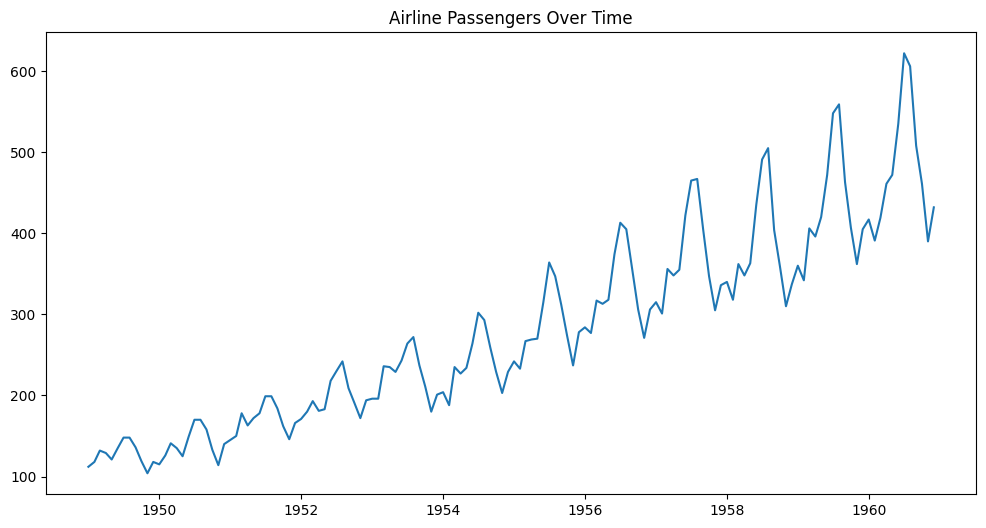

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['Passengers'])

plt.title("Airline Passengers Over Time")

plt.show()

# Rolling Mean

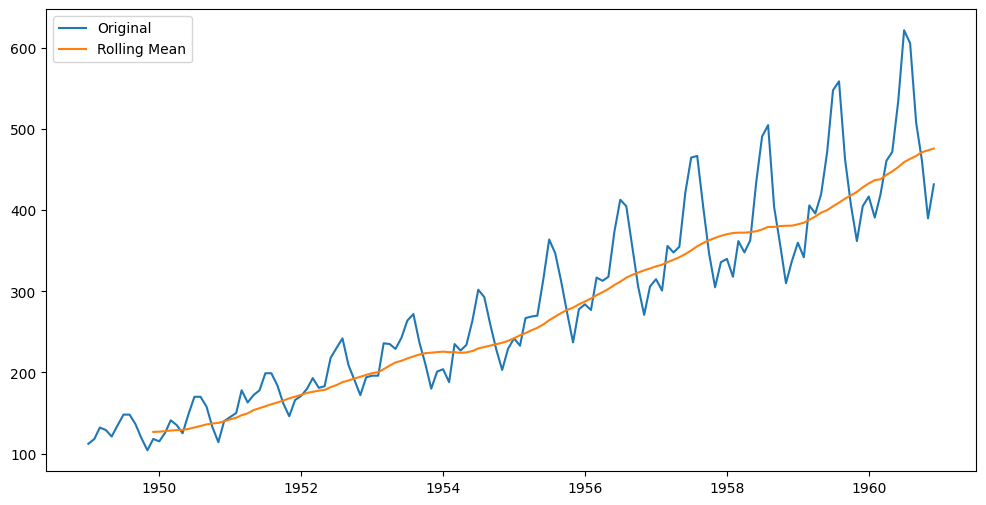

In [12]:
rolling_mean = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(df['Passengers'],label='Original')
plt.plot(rolling_mean,label='Rolling Mean')

plt.legend()

plt.show()

# Train Test Split

In [13]:
train = df.iloc[:120]

test = df.iloc[120:]

print(train.shape)
print(test.shape)

(120, 1)
(24, 1)


# Build ARIMA Model

In [14]:
model = ARIMA(
    train['Passengers'],
    order=(5,1,0)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -554.265
Date:                Mon, 22 Jun 2026   AIC                           1120.531
Time:                        14:41:05   BIC                           1137.206
Sample:                    01-01-1949   HQIC                          1127.302
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3015      0.097      3.101      0.002       0.111       0.492
ar.L2         -0.2301      0.106     -2.165      0.030      -0.438      -0.022
ar.L3         -0.0496      0.068     -0.734      0.4

# Forecast

In [15]:
forecast = model_fit.forecast(
    steps=len(test)
)

forecast

,predicted_mean
1959-01-01,390.436616
1959-02-01,412.193788
1959-03-01,418.256657
1959-04-01,401.933513
1959-05-01,379.237324
1959-06-01,371.493515
1959-07-01,374.279405
1959-08-01,383.331769
1959-09-01,392.088407
1959-10-01,393.895717


# Evaluation

In [16]:
mae = mean_absolute_error(
    test['Passengers'],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test['Passengers'],
        forecast
    )
)

print("MAE:",mae)

print("RMSE:",rmse)

MAE: 75.8922067645416
RMSE: 101.65923234647559


# Visualization

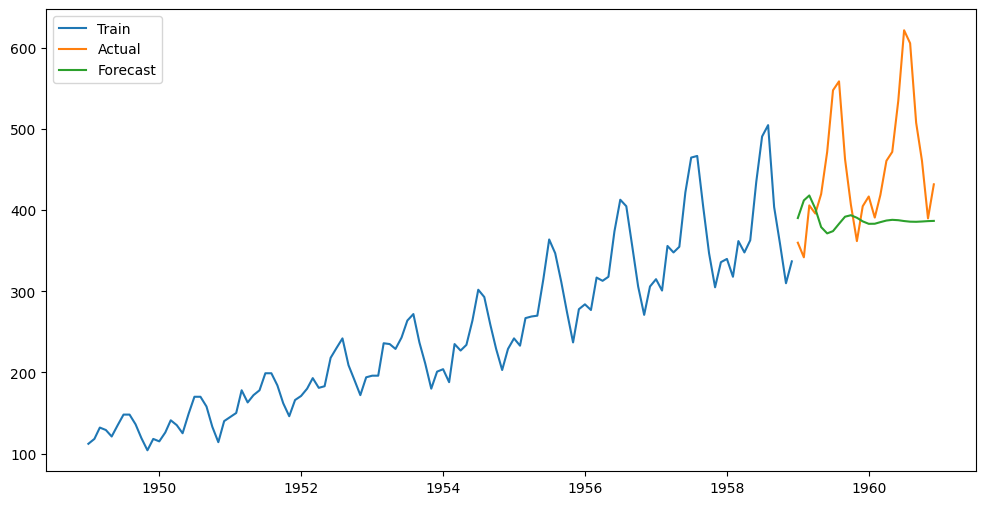

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Passengers'],
    label='Train'
)

plt.plot(
    test.index,
    test['Passengers'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.legend()

plt.show()

# Train Final Model

In [18]:
final_model = ARIMA(
    df['Passengers'],
    order=(5,1,0)
)

final_model_fit = final_model.fit()

# Save Model

In [19]:
import joblib

joblib.dump(
    final_model_fit,
    "forecast_model.pkl"
)

print("Model Saved")

Model Saved
